In [1]:
import numpy as np
import pandas as pd

import matplotlib.pyplot as plt
import seaborn as sns

In [2]:
pd.set_option("display.max_columns", None)

In [4]:
df = pd.read_csv("../data/WA_Fn-UseC_-Telco-Customer-Churn.csv")

In [5]:
df.head()

,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,OnlineBackup,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,7590-VHVEG,Female,0,Yes,No,1,No,No phone service,DSL,No,Yes,No,No,No,No,Month-to-month,Yes,Electronic check,29.85,29.85,No
1,5575-GNVDE,Male,0,No,No,34,Yes,No,DSL,Yes,No,Yes,No,No,No,One year,No,Mailed check,56.95,1889.5,No
2,3668-QPYBK,Male,0,No,No,2,Yes,No,DSL,Yes,Yes,No,No,No,No,Month-to-month,Yes,Mailed check,53.85,108.15,Yes
3,7795-CFOCW,Male,0,No,No,45,No,No phone service,DSL,Yes,No,Yes,Yes,No,No,One year,No,Bank transfer (automatic),42.30,1840.75,No
4,9237-HQITU,Female,0,No,No,2,Yes,No,Fiber optic,No,No,No,No,No,No,Month-to-month,Yes,Electronic check,70.70,151.65,Yes


In [6]:
df.shape

(7043, 21)

In [7]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 7043 entries, 0 to 7042
Data columns (total 21 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   customerID        7043 non-null   str    
 1   gender            7043 non-null   str    
 2   SeniorCitizen     7043 non-null   int64  
 3   Partner           7043 non-null   str    
 4   Dependents        7043 non-null   str    
 5   tenure            7043 non-null   int64  
 6   PhoneService      7043 non-null   str    
 7   MultipleLines     7043 non-null   str    
 8   InternetService   7043 non-null   str    
 9   OnlineSecurity    7043 non-null   str    
 10  OnlineBackup      7043 non-null   str    
 11  DeviceProtection  7043 non-null   str    
 12  TechSupport       7043 non-null   str    
 13  StreamingTV       7043 non-null   str    
 14  StreamingMovies   7043 non-null   str    
 15  Contract          7043 non-null   str    
 16  PaperlessBilling  7043 non-null   str    
 17  Paymen

In [8]:
df.describe(include="all").T

,count,unique,top,freq,mean,std,min,25%,50%,75%,max
customerID,7043,7043,7590-VHVEG,1,NaN,NaN,NaN,NaN,NaN,NaN,NaN
gender,7043,2,Male,3555,NaN,NaN,NaN,NaN,NaN,NaN,NaN
SeniorCitizen,7043.0,NaN,NaN,NaN,0.162147,0.368612,0.0,0.0,0.0,0.0,1.0
Partner,7043,2,No,3641,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Dependents,7043,2,No,4933,NaN,NaN,NaN,NaN,NaN,NaN,NaN
tenure,7043.0,NaN,NaN,NaN,32.371149,24.559481,0.0,9.0,29.0,55.0,72.0
PhoneService,7043,2,Yes,6361,NaN,NaN,NaN,NaN,NaN,NaN,NaN
MultipleLines,7043,3,No,3390,NaN,NaN,NaN,NaN,NaN,NaN,NaN
InternetService,7043,3,Fiber optic,3096,NaN,NaN,NaN,NaN,NaN,NaN,NaN
OnlineSecurity,7043,3,No,3498,NaN,NaN,NaN,NaN,NaN,NaN,NaN


In [9]:
df.isnull().sum()

customerID          0
gender              0
SeniorCitizen       0
Partner             0
Dependents          0
tenure              0
PhoneService        0
MultipleLines       0
InternetService     0
OnlineSecurity      0
OnlineBackup        0
DeviceProtection    0
TechSupport         0
StreamingTV         0
StreamingMovies     0
Contract            0
PaperlessBilling    0
PaymentMethod       0
MonthlyCharges      0
TotalCharges        0
Churn               0
dtype: int64

In [10]:
missing_percentage = (df.isnull().sum() / len(df)) * 100

missing_percentage[missing_percentage > 0]

Series([], dtype: float64)

In [11]:
df.duplicated().sum()

np.int64(0)

In [12]:
df.dtypes

customerID              str
gender                  str
SeniorCitizen         int64
Partner                 str
Dependents              str
tenure                int64
PhoneService            str
MultipleLines           str
InternetService         str
OnlineSecurity          str
OnlineBackup            str
DeviceProtection        str
TechSupport             str
StreamingTV             str
StreamingMovies         str
Contract                str
PaperlessBilling        str
PaymentMethod           str
MonthlyCharges      float64
TotalCharges            str
Churn                   str
dtype: object

In [13]:
df["TotalCharges"].value_counts().head(20)

TotalCharges
20.2     11
         11
19.75     9
19.9      8
20.05     8
19.65     8
45.3      7
19.55     7
20.15     6
19.45     6
20.25     6
20.45     5
20.3      5
74.7      4
70.6      4
44        4
75.3      4
20.4      4
19.85     4
49.9      4
Name: count, dtype: int64

In [14]:
(df["TotalCharges"].str.strip() == "").sum()

np.int64(11)

### Handling Missing Values in TotalCharges

The `TotalCharges` feature represents the total amount charged to a customer and should be a numerical variable.

During the data quality check, we found that the column was stored as an `object` data type instead of a numerical type. We also identified 11 blank string values in this column.

These blank values occur because some customers have a very short tenure and have not accumulated a recorded total charge.

Instead of treating blank strings as valid values, we will:

1. Remove leading/trailing whitespace.
2. Convert the column to a numerical data type.
3. Convert invalid or blank values into `NaN`.
4. Handle the resulting missing values appropriately.

This ensures that `TotalCharges` is correctly represented as a numerical feature before performing EDA and Machine Learning.

In [15]:
df["TotalCharges"] = df["TotalCharges"].str.strip()

In [16]:
df["TotalCharges"] = pd.to_numeric(df["TotalCharges"], errors="coerce")

In [17]:
df["TotalCharges"].dtype

dtype('float64')

In [18]:
df["TotalCharges"].isnull().sum()

np.int64(11)

### Investigating Missing TotalCharges Records

Only 11 customers have missing values in `TotalCharges`, representing approximately 0.16% of the dataset.

Before deciding how to handle these records, we will inspect their `tenure` and `Churn` values.

If these customers have a tenure of zero, the missing total charge is understandable because they have only recently joined the service.

Since the number of affected records is extremely small, removing these records is preferable to introducing an artificial value through imputation.

In [19]:
df[df["TotalCharges"].isnull()][["tenure", "MonthlyCharges", "TotalCharges", "Churn"]]

,tenure,MonthlyCharges,TotalCharges,Churn
488,0,52.55,NaN,No
753,0,20.25,NaN,No
936,0,80.85,NaN,No
1082,0,25.75,NaN,No
1340,0,56.05,NaN,No
3331,0,19.85,NaN,No
3826,0,25.35,NaN,No
4380,0,20.00,NaN,No
5218,0,19.70,NaN,No
6670,0,73.35,NaN,No


In [20]:
df = df.dropna(subset=["TotalCharges"]).copy()

In [21]:
print("Dataset shape:", df.shape)
print("Missing TotalCharges:", df["TotalCharges"].isnull().sum())

Dataset shape: (7032, 21)
Missing TotalCharges: 0


In [22]:
df.info()

<class 'pandas.DataFrame'>
Index: 7032 entries, 0 to 7042
Data columns (total 21 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   customerID        7032 non-null   str    
 1   gender            7032 non-null   str    
 2   SeniorCitizen     7032 non-null   int64  
 3   Partner           7032 non-null   str    
 4   Dependents        7032 non-null   str    
 5   tenure            7032 non-null   int64  
 6   PhoneService      7032 non-null   str    
 7   MultipleLines     7032 non-null   str    
 8   InternetService   7032 non-null   str    
 9   OnlineSecurity    7032 non-null   str    
 10  OnlineBackup      7032 non-null   str    
 11  DeviceProtection  7032 non-null   str    
 12  TechSupport       7032 non-null   str    
 13  StreamingTV       7032 non-null   str    
 14  StreamingMovies   7032 non-null   str    
 15  Contract          7032 non-null   str    
 16  PaperlessBilling  7032 non-null   str    
 17  PaymentMeth

### Inspecting Categorical Features

The dataset contains several categorical features such as gender, contract type,
internet service, payment method, and subscribed services.

Before encoding these variables for Machine Learning, we need to inspect their unique
categories.

This helps us identify unexpected values, inconsistent labels, or categories that may
require cleaning.

In [24]:
categorical_columns = df.select_dtypes(include="object").columns

for col in categorical_columns:
    print(f"\n{col}:")
    print(df[col].unique())


customerID:
<ArrowStringArray>
['7590-VHVEG', '5575-GNVDE', '3668-QPYBK', '7795-CFOCW', '9237-HQITU',
 '9305-CDSKC', '1452-KIOVK', '6713-OKOMC', '7892-POOKP', '6388-TABGU',
 ...
 '9767-FFLEM', '0639-TSIQW', '8456-QDAVC', '7750-EYXWZ', '2569-WGERO',
 '6840-RESVB', '2234-XADUH', '4801-JZAZL', '8361-LTMKD', '3186-AJIEK']
Length: 7032, dtype: str

gender:
<ArrowStringArray>
['Female', 'Male']
Length: 2, dtype: str

Partner:
<ArrowStringArray>
['Yes', 'No']
Length: 2, dtype: str

Dependents:
<ArrowStringArray>
['No', 'Yes']
Length: 2, dtype: str

PhoneService:
<ArrowStringArray>
['No', 'Yes']
Length: 2, dtype: str

MultipleLines:
<ArrowStringArray>
['No phone service', 'No', 'Yes']
Length: 3, dtype: str

InternetService:
<ArrowStringArray>
['DSL', 'Fiber optic', 'No']
Length: 3, dtype: str

OnlineSecurity:
<ArrowStringArray>
['No', 'Yes', 'No internet service']
Length: 3, dtype: str

OnlineBackup:
<ArrowStringArray>
['Yes', 'No', 'No internet service']
Length: 3, dtype: str

DeviceProtecti

C:\Users\shriv\AppData\Local\Temp\ipykernel_19372\4033208276.py:1: Pandas4Warning: For backward compatibility, 'str' dtypes are included by select_dtypes when 'object' dtype is specified. This behavior is deprecated and will be removed in a future version. Explicitly pass 'str' to `include` to select them, or to `exclude` to remove them and silence this warning.
See https://pandas.pydata.org/docs/user_guide/migration-3-strings.html#string-migration-select-dtypes for details on how to write code that works with pandas 2 and 3.
  categorical_columns = df.select_dtypes(include="object").columns


### Checking the Target Variable

The target variable for this project is `Churn`.

It is a binary categorical variable:

- `Yes` → Customer churned
- `No` → Customer stayed

Before starting Exploratory Data Analysis, we will check the available classes and their
distribution.

Understanding the target distribution is important because an imbalanced target can make
accuracy alone an unreliable evaluation metric.

In [25]:
df["Churn"].value_counts()

Churn
No     5163
Yes    1869
Name: count, dtype: int64

In [26]:
df["Churn"].value_counts(normalize=True) * 100

Churn
No     73.421502
Yes    26.578498
Name: proportion, dtype: float64

### Checking for Unnecessary Columns

The `customerID` column is a unique identifier for each customer. Since it does not
represent customer behavior or characteristics, it is not expected to provide useful
predictive information for churn.

We will first verify whether each customer has a unique ID before deciding how to
handle this column.

In [27]:
df["customerID"].nunique(), len(df)

(7032, 7032)

### Removing the Customer ID

Since `customerID` is only a unique identifier and does not provide meaningful
predictive information, it will be removed from the dataset before model training.

Removing it prevents the Machine Learning model from treating an arbitrary customer
identifier as a useful feature.

In [28]:
df.drop("customerID", axis=1, inplace=True)

In [29]:
df.columns

Index(['gender', 'SeniorCitizen', 'Partner', 'Dependents', 'tenure',
       'PhoneService', 'MultipleLines', 'InternetService', 'OnlineSecurity',
       'OnlineBackup', 'DeviceProtection', 'TechSupport', 'StreamingTV',
       'StreamingMovies', 'Contract', 'PaperlessBilling', 'PaymentMethod',
       'MonthlyCharges', 'TotalCharges', 'Churn'],
      dtype='str')

## Target Variable Analysis

The target variable in this project is `Churn`.

It indicates whether a customer has left the company:

- `Yes` → Customer churned
- `No` → Customer stayed

Before building a Machine Learning model, it is important to understand the distribution
of the target variable.

If the classes are imbalanced, accuracy alone may not be sufficient to evaluate the model.
Therefore, we will examine both the number and percentage of customers in each class.


In [30]:
df["Churn"].value_counts()

Churn
No     5163
Yes    1869
Name: count, dtype: int64

In [31]:
df["Churn"].value_counts(normalize=True) * 100

Churn
No     73.421502
Yes    26.578498
Name: proportion, dtype: float64

##  Churn Distribution

We will first visualize the distribution of the target variable, `Churn`.

Understanding the proportion of customers who churned versus those who stayed is important
because it helps us understand the class balance of the prediction problem.

A highly imbalanced target can make accuracy misleading, so this distribution will also help
us decide which evaluation metrics should receive more attention during model evaluation.

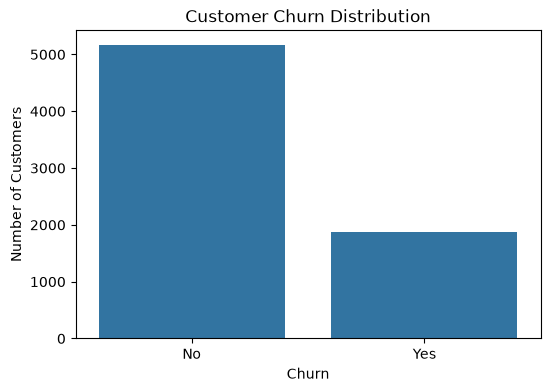

In [32]:
plt.figure(figsize=(6, 4))

sns.countplot(data=df, x="Churn")

plt.title("Customer Churn Distribution")
plt.xlabel("Churn")
plt.ylabel("Number of Customers")

plt.show()

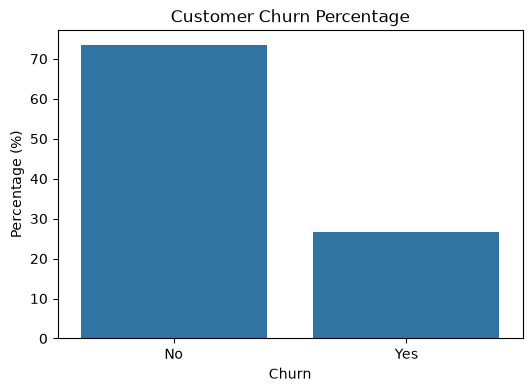

In [33]:
churn_percentage = df["Churn"].value_counts(normalize=True) * 100

plt.figure(figsize=(6, 4))

sns.barplot(
    x=churn_percentage.index,
    y=churn_percentage.values
)

plt.title("Customer Churn Percentage")
plt.xlabel("Churn")
plt.ylabel("Percentage (%)")

plt.show()

##  Numerical Feature Analysis

The dataset contains three primary numerical features:

- `tenure` — Number of months the customer has stayed with the company
- `MonthlyCharges` — Customer's monthly service charge
- `TotalCharges` — Total amount charged to the customer

We will first examine the distribution of these numerical variables to understand their
range, spread, and general patterns.

Histograms will help us identify the shape of the distributions and potential skewness
before comparing these features across churn groups.

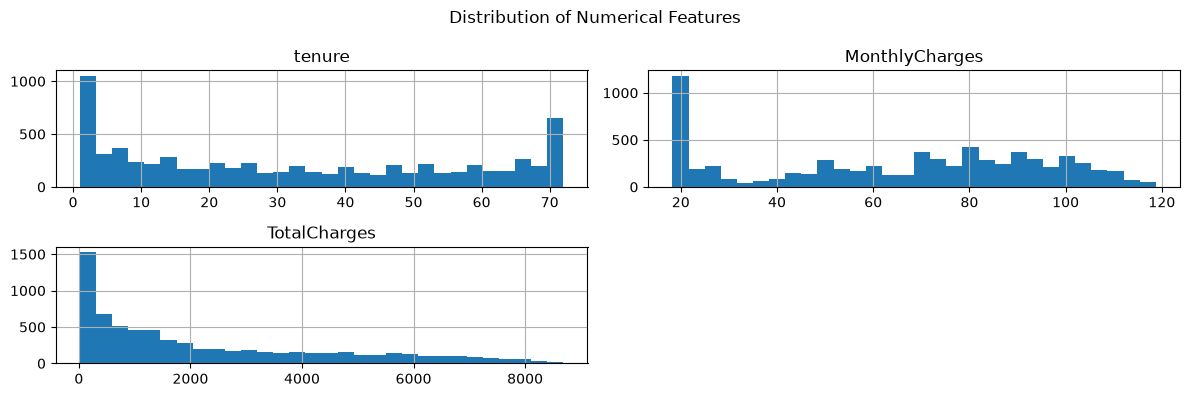

In [34]:
numerical_columns = ["tenure", "MonthlyCharges", "TotalCharges"]

df[numerical_columns].hist(
    figsize=(12, 4),
    bins=30
)

plt.suptitle("Distribution of Numerical Features")
plt.tight_layout()
plt.show()

### Numerical Features vs Churn

Understanding the overall distribution of numerical variables is useful, but it does not
directly tell us how these variables are related to customer churn.

Therefore, we will compare the distributions of `tenure`, `MonthlyCharges`, and
`TotalCharges` between customers who churned and customers who stayed.

Boxplots are useful for this comparison because they show the median, spread, and potential
outliers for each churn group.

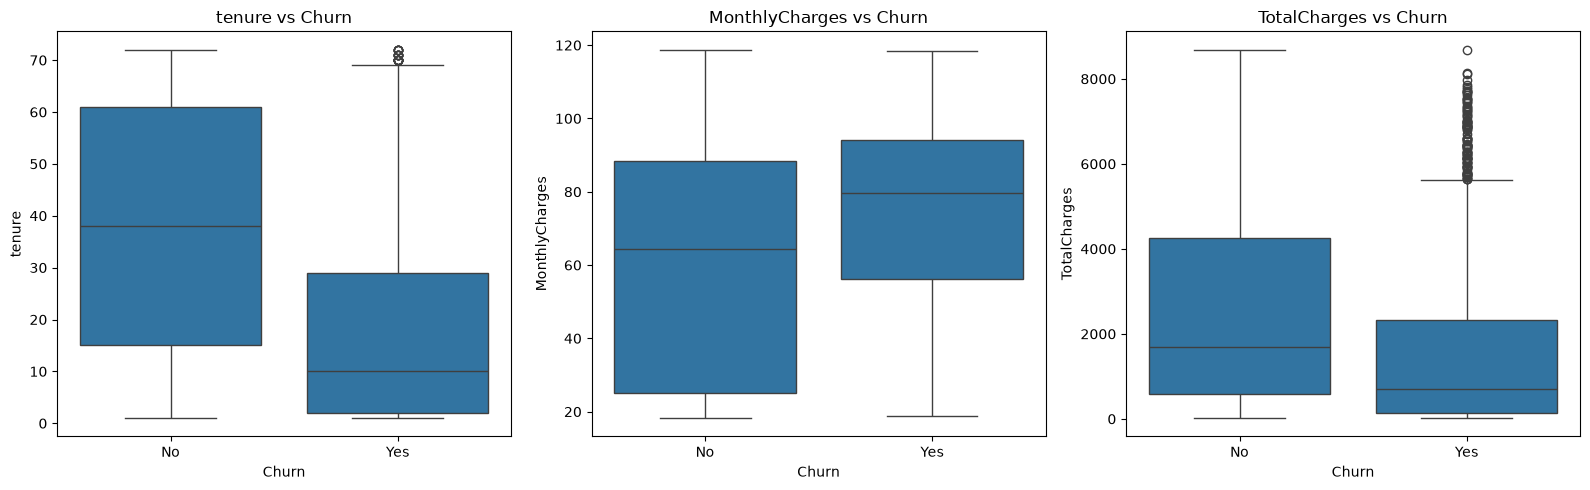

In [36]:
fig, axes = plt.subplots(1, 3, figsize=(16, 5))

for i, col in enumerate(numerical_columns):
    sns.boxplot(data=df, x="Churn", y=col, ax=axes[i])
    axes[i].set_title(f"{col} vs Churn")

plt.tight_layout()
plt.show()

##  Categorical Features vs Churn

Categorical variables can reveal important customer segments that have different churn
behavior.

We will compare selected categorical features against the target variable, `Churn`, to
identify customer groups with noticeably different churn patterns.

We will begin with demographic characteristics and then investigate service and account
related features.

### Gender vs Churn

We first examine whether churn behavior differs significantly between male and female
customers.

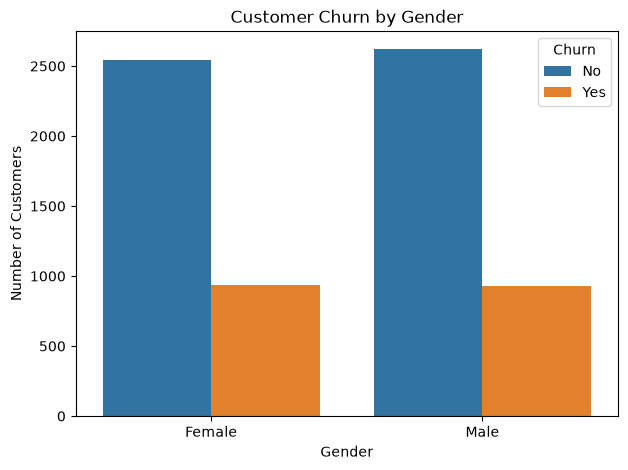

In [37]:
plt.figure(figsize=(7, 5))

sns.countplot(data=df, x="gender", hue="Churn")

plt.title("Customer Churn by Gender")
plt.xlabel("Gender")
plt.ylabel("Number of Customers")

plt.show()

### Contract Type vs Churn

Contract type is an important business feature because customers with different contract
commitments may have different levels of churn risk.

We will compare churn across:

- Month-to-month
- One year
- Two year

This can help identify whether customers with shorter contracts are more likely to leave.

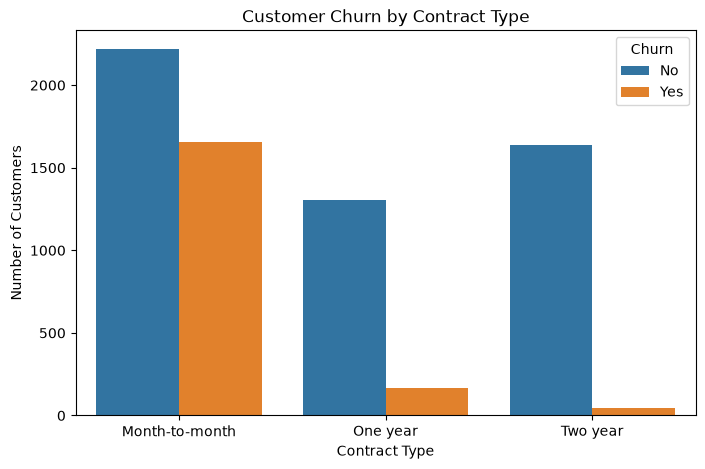

In [38]:
plt.figure(figsize=(8, 5))

sns.countplot(
    data=df,
    x="Contract",
    hue="Churn"
)

plt.title("Customer Churn by Contract Type")
plt.xlabel("Contract Type")
plt.ylabel("Number of Customers")

plt.show()

### Internet Service vs Churn

Internet service type may influence customer churn because different service types can
have different pricing, performance, and customer expectations.

We will compare churn across DSL, Fiber optic, and customers without internet service.

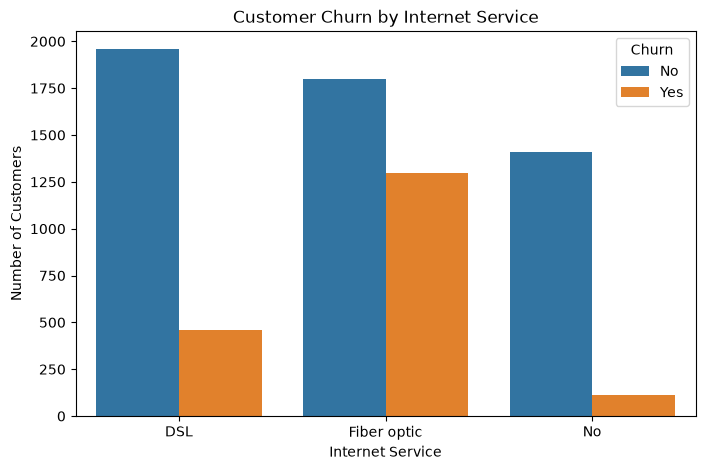

In [39]:
plt.figure(figsize=(8, 5))

sns.countplot(
    data=df,
    x="InternetService",
    hue="Churn"
)

plt.title("Customer Churn by Internet Service")
plt.xlabel("Internet Service")
plt.ylabel("Number of Customers")

plt.show()

### Payment Method vs Churn

Payment method may be associated with customer churn because different payment methods
can reflect different customer preferences and payment experiences.

We will compare churn across the available payment methods to identify whether certain
payment methods are associated with higher churn.

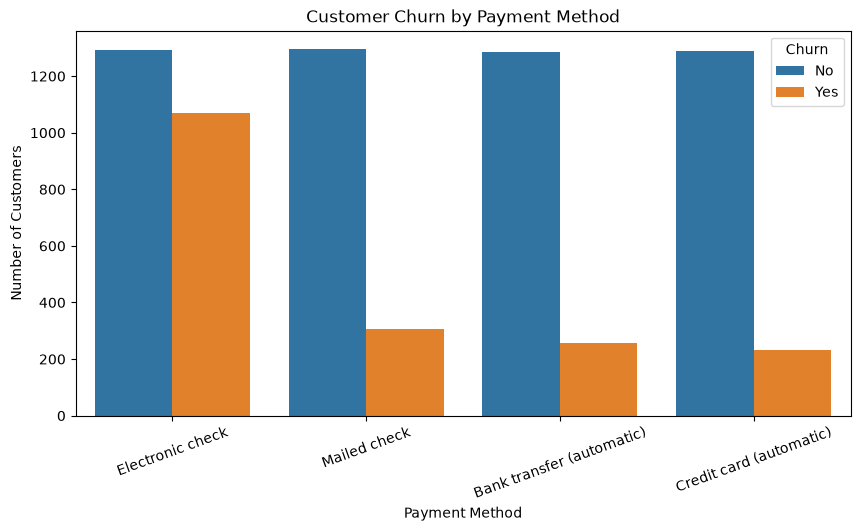

In [40]:
plt.figure(figsize=(10, 5))

sns.countplot(
    data=df,
    x="PaymentMethod",
    hue="Churn"
)

plt.title("Customer Churn by Payment Method")
plt.xlabel("Payment Method")
plt.ylabel("Number of Customers")
plt.xticks(rotation=20)

plt.show()

### Tech Support vs Churn

Technical support is an important service-related feature.

Customers without technical support may have different churn behavior compared with
customers who have access to technical support.

We will compare churn across these groups to identify any noticeable relationship.

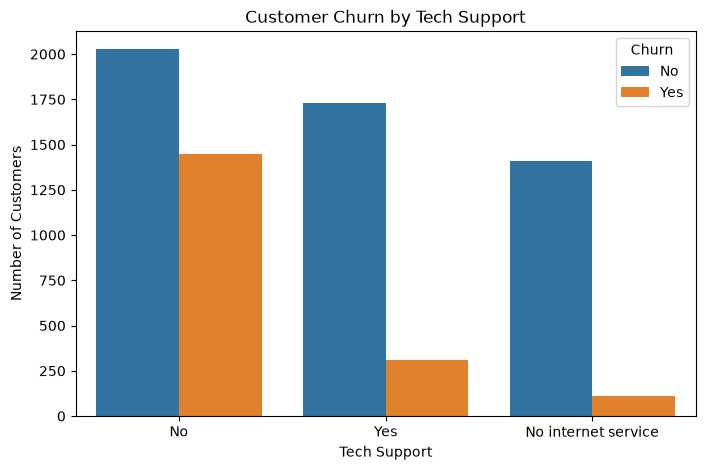

In [41]:
plt.figure(figsize=(8, 5))

sns.countplot(
    data=df,
    x="TechSupport",
    hue="Churn"
)

plt.title("Customer Churn by Tech Support")
plt.xlabel("Tech Support")
plt.ylabel("Number of Customers")

plt.show()

### Senior Citizen Status vs Churn

Customer age-related characteristics can also influence churn behavior.

The `SeniorCitizen` variable is encoded as:

- `0` → Not a senior citizen
- `1` → Senior citizen

We will compare churn behavior between these two groups.

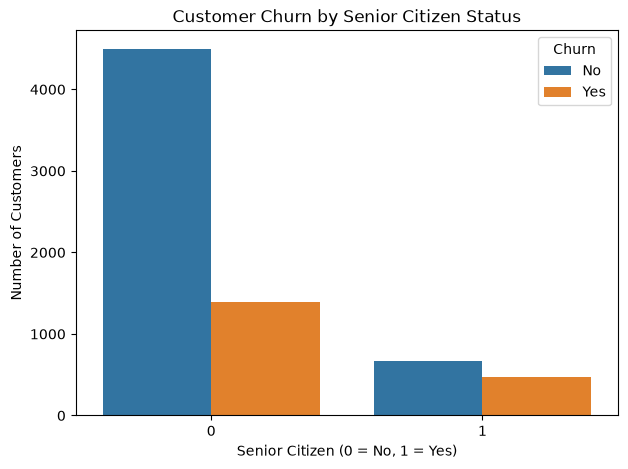

In [42]:
plt.figure(figsize=(7, 5))

sns.countplot(
    data=df,
    x="SeniorCitizen",
    hue="Churn"
)

plt.title("Customer Churn by Senior Citizen Status")
plt.xlabel("Senior Citizen (0 = No, 1 = Yes)")
plt.ylabel("Number of Customers")

plt.show()

##  Churn Rate Analysis

Count plots show the number of customers in each category, but they do not account for
differences in group size.

For business analysis, churn rate is more useful because it tells us what percentage of
customers within a particular group actually churned.

We will calculate category-wise churn rates to identify customer segments with relatively
higher churn risk.

### Contract-wise Churn Rate

We will calculate the percentage of customers who churn within each contract type.

This allows us to compare churn risk fairly across month-to-month, one-year, and two-year
contract customers.

In [43]:
contract_churn_rate = pd.crosstab(
    df["Contract"],
    df["Churn"],
    normalize="index"
) * 100

contract_churn_rate

Churn,No,Yes
Contract,,
Month-to-month,57.290323,42.709677
One year,88.722826,11.277174
Two year,97.151335,2.848665


### Internet Service-wise Churn Rate

We will now calculate the churn rate for each type of internet service.

This helps determine whether certain internet service segments have a higher proportion
of customers leaving the company.

In [44]:
internet_churn_rate = pd.crosstab(
    df["InternetService"],
    df["Churn"],
    normalize="index"
) * 100

internet_churn_rate

Churn,No,Yes
InternetService,,
DSL,81.001656,18.998344
Fiber optic,58.107235,41.892765
No,92.565789,7.434211


### Payment Method-wise Churn Rate

Payment method was previously examined using customer counts.

We will now calculate the churn rate for each payment method to determine whether some
payment methods are associated with a higher proportion of churned customers.

In [45]:
payment_churn_rate = pd.crosstab(
    df["PaymentMethod"],
    df["Churn"],
    normalize="index"
) * 100

payment_churn_rate

Churn,No,Yes
PaymentMethod,,
Bank transfer (automatic),83.268482,16.731518
Credit card (automatic),84.746877,15.253123
Electronic check,54.714588,45.285412
Mailed check,80.798005,19.201995


payment_churn_rate = pd.crosstab(
    df["PaymentMethod"],
    df["Churn"],
    normalize="index"
) * 100

payment_churn_rate

In [46]:
internet_churn_rate = pd.crosstab(
    df["InternetService"],
    df["Churn"],
    normalize="index"
) * 100

internet_churn_rate

Churn,No,Yes
InternetService,,
DSL,81.001656,18.998344
Fiber optic,58.107235,41.892765
No,92.565789,7.434211


In [47]:
payment_churn_rate = pd.crosstab(
    df["PaymentMethod"],
    df["Churn"],
    normalize="index"
) * 100

payment_churn_rate

Churn,No,Yes
PaymentMethod,,
Bank transfer (automatic),83.268482,16.731518
Credit card (automatic),84.746877,15.253123
Electronic check,54.714588,45.285412
Mailed check,80.798005,19.201995


In [48]:
techsupport_churn_rate = pd.crosstab(
    df["TechSupport"],
    df["Churn"],
    normalize="index"
) * 100

techsupport_churn_rate

Churn,No,Yes
TechSupport,,
No,58.352535,41.647465
No internet service,92.565789,7.434211
Yes,84.803922,15.196078


In [49]:
senior_churn_rate = pd.crosstab(
    df["SeniorCitizen"],
    df["Churn"],
    normalize="index"
) * 100

senior_churn_rate

Churn,No,Yes
SeniorCitizen,,
0,76.349745,23.650255
1,58.318739,41.681261


In [50]:
senior_churn_rate = pd.crosstab(
    df["SeniorCitizen"],
    df["Churn"],
    normalize="index"
) * 100

senior_churn_rate

Churn,No,Yes
SeniorCitizen,,
0,76.349745,23.650255
1,58.318739,41.681261


In [51]:
df_corr = df.copy()

df_corr["Churn"] = df_corr["Churn"].map({
    "No": 0,
    "Yes": 1
})

correlation = df_corr.corr(numeric_only=True)

correlation["Churn"].sort_values(ascending=False)

Churn             1.000000
MonthlyCharges    0.192858
SeniorCitizen     0.150541
TotalCharges     -0.199484
tenure           -0.354049
Name: Churn, dtype: float64

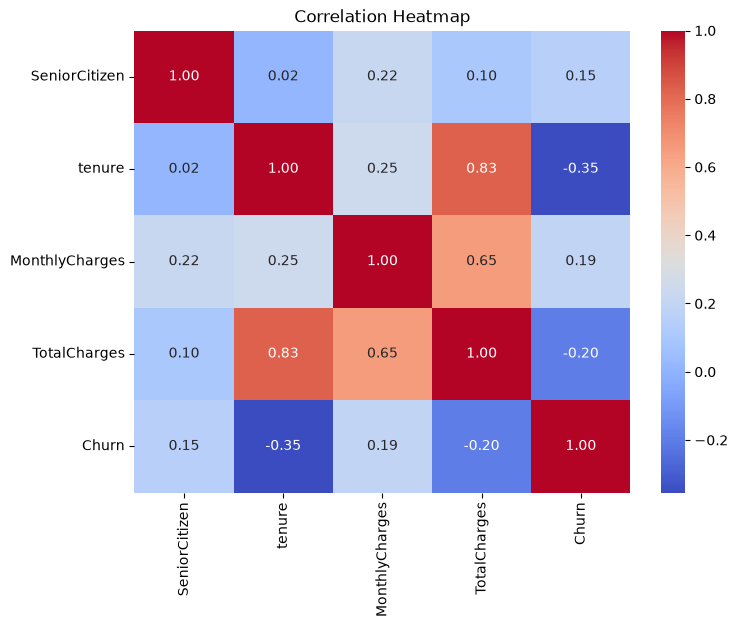

In [52]:
plt.figure(figsize=(8, 6))

sns.heatmap(
    correlation,
    annot=True,
    cmap="coolwarm",
    fmt=".2f"
)

plt.title("Correlation Heatmap")
plt.show()

### Key Business Insights from EDA

The exploratory data analysis revealed several important patterns:

1. Customers with month-to-month contracts have a much higher churn rate than customers with one-year or two-year contracts.

2. Fiber optic internet customers show a relatively high churn rate compared with DSL and customers without internet service.

3. Customers using electronic check as their payment method have the highest churn rate.

4. Customers without Tech Support or Online Security tend to have higher churn rates.

5. Senior citizens have a higher churn rate compared with non-senior citizens.

6. Customers with shorter tenure are more likely to churn.

7. Higher monthly charges are generally associated with higher churn.

8. The dataset contains a moderate class imbalance, with approximately 26% churned customers and 74% non-churned customers.

These insights will help guide the feature engineering and machine learning modeling stages.

### Feature Engineering — Total Services

We create a new feature called `TotalServices`.

This feature represents the total number of active services used by a customer.

For service columns, only the value `Yes` is counted as an active service.
Values such as `No` and `No internet service` are not counted.

This feature may help identify whether customers with fewer or more subscribed
services have different churn behavior.

In [53]:
service_columns = [
    "PhoneService",
    "MultipleLines",
    "OnlineSecurity",
    "OnlineBackup",
    "DeviceProtection",
    "TechSupport",
    "StreamingTV",
    "StreamingMovies"
]

df["TotalServices"] = (
    df[service_columns]
    .eq("Yes")
    .sum(axis=1)
)

df[["TotalServices", "Churn"]].head()

,TotalServices,Churn
0,1,No
1,3,No
2,3,Yes
3,3,No
4,1,Yes


### Total Services vs Churn

We will analyze the relationship between the newly created `TotalServices`
feature and customer churn.

This helps us understand whether customers using fewer or more services
show different churn behavior.

In [54]:
services_churn_rate = pd.crosstab(
    df["TotalServices"],
    df["Churn"],
    normalize="index"
) * 100

services_churn_rate

Churn,No,Yes
TotalServices,,
0,56.250000,43.750000
1,78.845021,21.154979
2,67.116358,32.883642
3,63.523316,36.476684
4,68.621064,31.378936
5,74.392936,25.607064
6,77.448071,22.551929
7,87.594937,12.405063
8,94.711538,5.288462


### Feature Engineering — Tenure Group

We create a categorical `TenureGroup` feature from the customer's tenure.

This groups customers into different lifecycle stages and can help the model
capture non-linear patterns between customer tenure and churn.

In [55]:
df["TenureGroup"] = pd.cut(
    df["tenure"],
    bins=[-1, 12, 24, 48, 72],
    labels=["New", "Early", "Medium", "Long-term"]
)

df[["tenure", "TenureGroup"]].head(10)

,tenure,TenureGroup
0,1,New
1,34,Medium
2,2,New
3,45,Medium
4,2,New
5,8,New
6,22,Early
7,10,New
8,28,Medium
9,62,Long-term


### Tenure Group vs Churn

We will calculate the churn rate for each tenure group.

This helps us understand how customer lifecycle stage is related to churn.

In [56]:
tenure_group_churn_rate = pd.crosstab(
    df["TenureGroup"],
    df["Churn"],
    normalize="index"
) * 100

tenure_group_churn_rate

Churn,No,Yes
TenureGroup,,
New,52.321839,47.678161
Early,71.289062,28.710938
Medium,79.611041,20.388959
Long-term,90.486824,9.513176


### Verify Feature Engineering

We will verify that the newly created features are present in the dataset
and inspect their basic information.

In [57]:
new_features = ["TotalServices", "TenureGroup"]

print("New features:")
print(new_features)

print("\nDataset shape:", df.shape)

print("\nNew feature data types:")
print(df[new_features].dtypes)

New features:
['TotalServices', 'TenureGroup']

Dataset shape: (7032, 22)

New feature data types:
TotalServices       int64
TenureGroup      category
dtype: object


### Separating Features and Target

The target variable is `Churn`, which represents whether a customer
left the company.

We separate the input features (`X`) from the target variable (`y`)
before building the machine learning models.

In [58]:
X = df.drop("Churn", axis=1)
y = df["Churn"]

print("X shape:", X.shape)
print("y shape:", y.shape)

print("\nTarget values:")
print(y.value_counts())

X shape: (7032, 21)
y shape: (7032,)

Target values:
Churn
No     5163
Yes    1869
Name: count, dtype: int64


### Identifying Numerical and Categorical Features

Machine learning models require numerical input.

The dataset contains both numerical and categorical features, so we will
process them separately.

Numerical features will be scaled, while categorical features will be
converted into numerical form using One-Hot Encoding.

In [59]:
numerical_features = X.select_dtypes(
    include=["int64", "float64"]
).columns.tolist()

categorical_features = X.select_dtypes(
    include=["object", "category"]
).columns.tolist()

print("Numerical features:")
print(numerical_features)

print("\nCategorical features:")
print(categorical_features)

print("\nNumber of numerical features:", len(numerical_features))
print("Number of categorical features:", len(categorical_features))

Numerical features:
['SeniorCitizen', 'tenure', 'MonthlyCharges', 'TotalCharges', 'TotalServices']

Categorical features:
['gender', 'Partner', 'Dependents', 'PhoneService', 'MultipleLines', 'InternetService', 'OnlineSecurity', 'OnlineBackup', 'DeviceProtection', 'TechSupport', 'StreamingTV', 'StreamingMovies', 'Contract', 'PaperlessBilling', 'PaymentMethod', 'TenureGroup']

Number of numerical features: 5
Number of categorical features: 16


C:\Users\shriv\AppData\Local\Temp\ipykernel_19372\2042692763.py:5: Pandas4Warning: For backward compatibility, 'str' dtypes are included by select_dtypes when 'object' dtype is specified. This behavior is deprecated and will be removed in a future version. Explicitly pass 'str' to `include` to select them, or to `exclude` to remove them and silence this warning.
See https://pandas.pydata.org/docs/user_guide/migration-3-strings.html#string-migration-select-dtypes for details on how to write code that works with pandas 2 and 3.
  categorical_features = X.select_dtypes(


### Train-Test Split

The dataset is divided into training and testing sets using an 80:20 ratio.

Stratified splitting is used to preserve the original distribution of the
target classes (`Churn`) in both training and testing datasets.

A fixed `random_state` ensures reproducible results.

In [60]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=42,
    stratify=y
)

print("X_train shape:", X_train.shape)
print("X_test shape:", X_test.shape)

print("\ny_train distribution:")
print(y_train.value_counts(normalize=True) * 100)

print("\ny_test distribution:")
print(y_test.value_counts(normalize=True) * 100)

X_train shape: (5625, 21)
X_test shape: (1407, 21)

y_train distribution:
Churn
No     73.422222
Yes    26.577778
Name: proportion, dtype: float64

y_test distribution:
Churn
No     73.418621
Yes    26.581379
Name: proportion, dtype: float64


### Building the Preprocessing Pipeline

Numerical and categorical features require different preprocessing steps.

For numerical features, missing values will be handled using median imputation
and the features will be standardized using StandardScaler.

For categorical features, missing values will be handled using the most frequent
value and categorical variables will be converted into numerical values using
OneHotEncoder.

A ColumnTransformer is used to apply the appropriate transformations to each
type of feature.

In [61]:
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import StandardScaler, OneHotEncoder

numerical_pipeline = Pipeline([
    ("imputer", SimpleImputer(strategy="median")),
    ("scaler", StandardScaler())
])

categorical_pipeline = Pipeline([
    ("imputer", SimpleImputer(strategy="most_frequent")),
    ("encoder", OneHotEncoder(handle_unknown="ignore"))
])

preprocessor = ColumnTransformer([
    ("num", numerical_pipeline, numerical_features),
    ("cat", categorical_pipeline, categorical_features)
])

print("Preprocessing pipeline created successfully.")

Preprocessing pipeline created successfully.


### Fitting and Applying the Preprocessor

The preprocessing pipeline is fitted only on the training data.

It is then used to transform the training data into a numerical representation
that can be provided to machine learning models.

The test data will be transformed later using the same fitted preprocessor.

In [62]:
X_train_processed = preprocessor.fit_transform(X_train)

print("Original X_train shape:", X_train.shape)
print("Processed X_train shape:", X_train_processed.shape)
print("Processed data type:", type(X_train_processed))

Original X_train shape: (5625, 21)
Processed X_train shape: (5625, 50)
Processed data type: <class 'numpy.ndarray'>


### Transforming the Test Data

The already fitted preprocessing pipeline is used to transform the test data.

We use `transform()` instead of `fit_transform()` so that no information
from the test set is used during preprocessing.

In [63]:
X_test_processed = preprocessor.transform(X_test)

print("Original X_test shape:", X_test.shape)
print("Processed X_test shape:", X_test_processed.shape)
print("Processed data type:", type(X_test_processed))

Original X_test shape: (1407, 21)
Processed X_test shape: (1407, 50)
Processed data type: <class 'numpy.ndarray'>


### Logistic Regression

Logistic Regression is used as the baseline classification model for predicting
customer churn.

The model estimates the probability that a customer will churn based on the
processed customer features.

In [64]:
from sklearn.linear_model import LogisticRegression

logistic_model = LogisticRegression(
    max_iter=1000,
    random_state=42
)

logistic_model.fit(X_train_processed, y_train)

print("Logistic Regression model trained successfully.")

Logistic Regression model trained successfully.


### Logistic Regression Predictions

The trained Logistic Regression model is used to predict the churn class
for the unseen test dataset.

The model predicts either `No` or `Yes` for each customer.

In [65]:
y_pred_logistic = logistic_model.predict(X_test_processed)

print("First 20 predictions:")
print(y_pred_logistic[:20])

print("\nNumber of predictions:", len(y_pred_logistic))

First 20 predictions:
['No' 'Yes' 'No' 'No' 'No' 'Yes' 'No' 'No' 'Yes' 'No' 'Yes' 'No' 'Yes'
 'No' 'No' 'Yes' 'Yes' 'No' 'No' 'No']

Number of predictions: 1407


### Evaluating Logistic Regression

The Logistic Regression model is evaluated using accuracy, precision, recall,
and F1-score.

Since customer churn is a moderately imbalanced classification problem,
precision, recall, and F1-score are considered along with accuracy.

In [66]:
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score
)

accuracy_logistic = accuracy_score(y_test, y_pred_logistic)
precision_logistic = precision_score(y_test, y_pred_logistic, pos_label="Yes")
recall_logistic = recall_score(y_test, y_pred_logistic, pos_label="Yes")
f1_logistic = f1_score(y_test, y_pred_logistic, pos_label="Yes")

print("Logistic Regression Performance")
print("--------------------------------")
print(f"Accuracy : {accuracy_logistic:.4f}")
print(f"Precision: {precision_logistic:.4f}")
print(f"Recall   : {recall_logistic:.4f}")
print(f"F1-Score : {f1_logistic:.4f}")

Logistic Regression Performance
--------------------------------
Accuracy : 0.7925
Precision: 0.6314
Recall   : 0.5267
F1-Score : 0.5743


### Confusion Matrix — Logistic Regression

A confusion matrix shows the number of correct and incorrect predictions
for each churn class.

It helps us understand how well the model identifies customers who are
likely to churn and customers who are likely to stay.

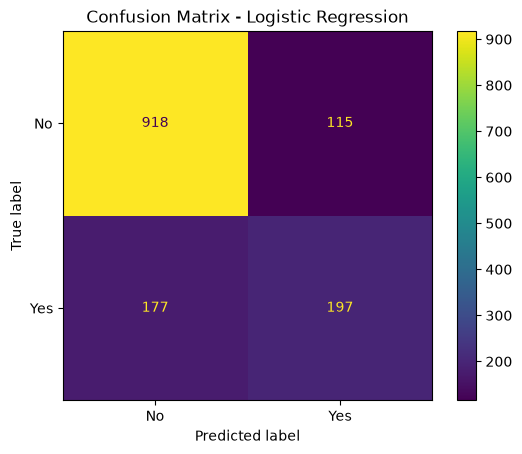

In [67]:
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay

cm_logistic = confusion_matrix(
    y_test,
    y_pred_logistic,
    labels=["No", "Yes"]
)

disp = ConfusionMatrixDisplay(
    confusion_matrix=cm_logistic,
    display_labels=["No", "Yes"]
)

disp.plot()
plt.title("Confusion Matrix - Logistic Regression")
plt.show()

### ROC-AUC — Logistic Regression

ROC-AUC measures how well the model can distinguish between customers
who churn and customers who do not churn across different classification
thresholds.

A higher ROC-AUC indicates better overall class-separation ability.

In [68]:
from sklearn.metrics import roc_auc_score

y_prob_logistic = logistic_model.predict_proba(X_test_processed)[:, 1]

roc_auc_logistic = roc_auc_score(
    (y_test == "Yes").astype(int),
    y_prob_logistic
)

print(f"ROC-AUC: {roc_auc_logistic:.4f}")

ROC-AUC: 0.8350


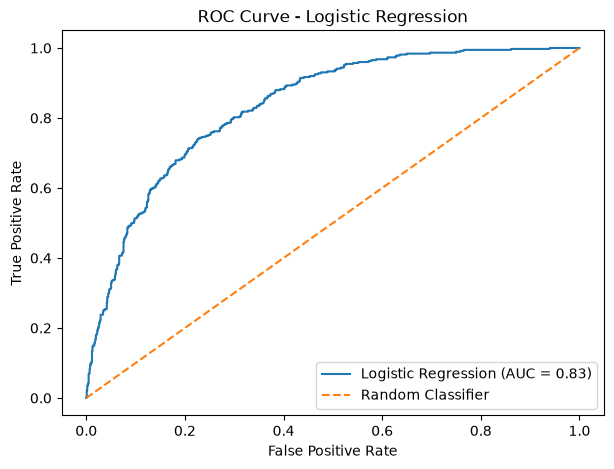

In [69]:
from sklearn.metrics import roc_curve

fpr_logistic, tpr_logistic, thresholds_logistic = roc_curve(
    (y_test == "Yes").astype(int),
    y_prob_logistic
)

plt.figure(figsize=(7, 5))

plt.plot(
    fpr_logistic,
    tpr_logistic,
    label=f"Logistic Regression (AUC = {roc_auc_logistic:.2f})"
)

plt.plot(
    [0, 1],
    [0, 1],
    linestyle="--",
    label="Random Classifier"
)

plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve - Logistic Regression")
plt.legend()
plt.show()

### Random Forest

Random Forest is an ensemble learning algorithm that combines multiple
decision trees to make predictions.

Unlike Logistic Regression, Random Forest can capture non-linear relationships
between customer features and churn.

In [70]:
from sklearn.ensemble import RandomForestClassifier

random_forest_model = RandomForestClassifier(
    n_estimators=200,
    random_state=42
)

random_forest_model.fit(X_train_processed, y_train)

print("Random Forest model trained successfully.")

Random Forest model trained successfully.


### Random Forest Predictions

The trained Random Forest model is used to predict whether customers
in the test dataset will churn or stay.

In [71]:
y_pred_rf = random_forest_model.predict(X_test_processed)

print("First 20 predictions:")
print(y_pred_rf[:20])

print("\nNumber of predictions:", len(y_pred_rf))

First 20 predictions:
['No' 'Yes' 'No' 'No' 'No' 'No' 'No' 'No' 'Yes' 'No' 'Yes' 'No' 'No' 'No'
 'No' 'Yes' 'Yes' 'Yes' 'No' 'No']

Number of predictions: 1407


### Evaluating Random Forest

The Random Forest model is evaluated using accuracy, precision, recall,
and F1-score.

These metrics will later be compared with Logistic Regression and
Gradient Boosting to select the most suitable model.

In [72]:
accuracy_rf = accuracy_score(y_test, y_pred_rf)
precision_rf = precision_score(y_test, y_pred_rf, pos_label="Yes")
recall_rf = recall_score(y_test, y_pred_rf, pos_label="Yes")
f1_rf = f1_score(y_test, y_pred_rf, pos_label="Yes")

print("Random Forest Performance")
print("-------------------------")
print(f"Accuracy : {accuracy_rf:.4f}")
print(f"Precision: {precision_rf:.4f}")
print(f"Recall   : {recall_rf:.4f}")
print(f"F1-Score : {f1_rf:.4f}")

Random Forest Performance
-------------------------
Accuracy : 0.7818
Precision: 0.6136
Recall   : 0.4840
F1-Score : 0.5411


### Confusion Matrix — Random Forest

The confusion matrix shows how many customers were correctly and incorrectly
classified as churned or non-churned by the Random Forest model.

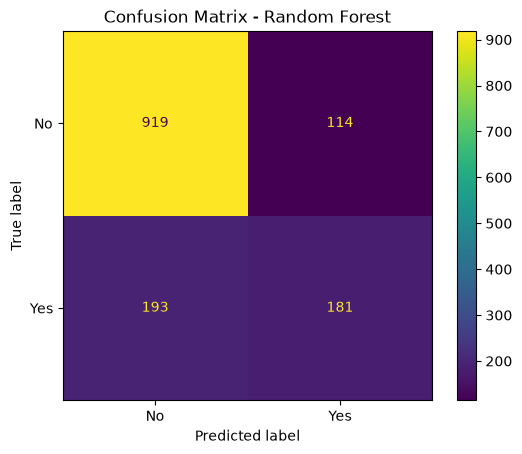

In [74]:
cm_rf = confusion_matrix(
    y_test,
    y_pred_rf,
    labels=["No", "Yes"]
)

disp = ConfusionMatrixDisplay(
    confusion_matrix=cm_rf,
    display_labels=["No", "Yes"]
)

disp.plot()
plt.title("Confusion Matrix - Random Forest")
plt.show()

### ROC-AUC — Random Forest

ROC-AUC measures how effectively the Random Forest model distinguishes
between customers who churn and customers who do not churn.

The probability of the positive class (`Yes`) is used to calculate AUC.

In [75]:
y_prob_rf = random_forest_model.predict_proba(X_test_processed)[:, 1]

roc_auc_rf = roc_auc_score(
    (y_test == "Yes").astype(int),
    y_prob_rf
)

print(f"ROC-AUC: {roc_auc_rf:.4f}")

ROC-AUC: 0.8147


### ROC Curve — Random Forest

The ROC curve visualizes the trade-off between the True Positive Rate
and False Positive Rate at different classification thresholds.

The AUC value summarizes the model's ability to distinguish between
churned and non-churned customers.

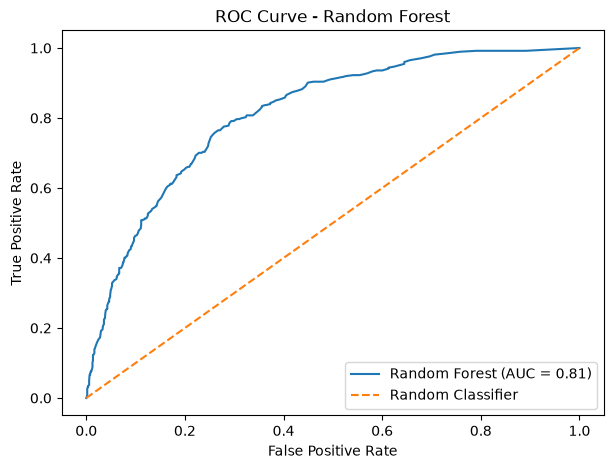

In [76]:
fpr_rf, tpr_rf, thresholds_rf = roc_curve(
    (y_test == "Yes").astype(int),
    y_prob_rf
)

plt.figure(figsize=(7, 5))

plt.plot(
    fpr_rf,
    tpr_rf,
    label=f"Random Forest (AUC = {roc_auc_rf:.2f})"
)

plt.plot(
    [0, 1],
    [0, 1],
    linestyle="--",
    label="Random Classifier"
)

plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve - Random Forest")
plt.legend()
plt.show()

### Gradient Boosting

Gradient Boosting is an ensemble learning algorithm that builds multiple
decision trees sequentially.

Each new tree attempts to improve the errors made by the previous trees,
allowing the model to capture complex non-linear patterns in the data.

In [77]:
from sklearn.ensemble import GradientBoostingClassifier

gradient_boosting_model = GradientBoostingClassifier(
    n_estimators=100,
    learning_rate=0.1,
    random_state=42
)

gradient_boosting_model.fit(X_train_processed, y_train)

print("Gradient Boosting model trained successfully.")

Gradient Boosting model trained successfully.


### Gradient Boosting Predictions

The trained Gradient Boosting model is used to predict whether customers
in the test dataset will churn or stay.

In [78]:
y_pred_gb = gradient_boosting_model.predict(X_test_processed)

print("First 20 predictions:")
print(y_pred_gb[:20])

print("\nNumber of predictions:", len(y_pred_gb))

First 20 predictions:
['No' 'Yes' 'No' 'No' 'No' 'No' 'No' 'No' 'Yes' 'No' 'Yes' 'No' 'Yes' 'No'
 'No' 'Yes' 'Yes' 'Yes' 'No' 'No']

Number of predictions: 1407


### Evaluating Gradient Boosting

The Gradient Boosting model is evaluated using accuracy, precision, recall,
and F1-score.

These results will be compared with the other two models to determine
which model performs best for customer churn prediction.

In [79]:
accuracy_gb = accuracy_score(y_test, y_pred_gb)
precision_gb = precision_score(y_test, y_pred_gb, pos_label="Yes")
recall_gb = recall_score(y_test, y_pred_gb, pos_label="Yes")
f1_gb = f1_score(y_test, y_pred_gb, pos_label="Yes")

print("Gradient Boosting Performance")
print("-----------------------------")
print(f"Accuracy : {accuracy_gb:.4f}")
print(f"Precision: {precision_gb:.4f}")
print(f"Recall   : {recall_gb:.4f}")
print(f"F1-Score : {f1_gb:.4f}")

Gradient Boosting Performance
-----------------------------
Accuracy : 0.7953
Precision: 0.6387
Recall   : 0.5294
F1-Score : 0.5789


### Confusion Matrix — Gradient Boosting

The confusion matrix shows how many customers were correctly and incorrectly
classified as churned or non-churned by the Gradient Boosting model.

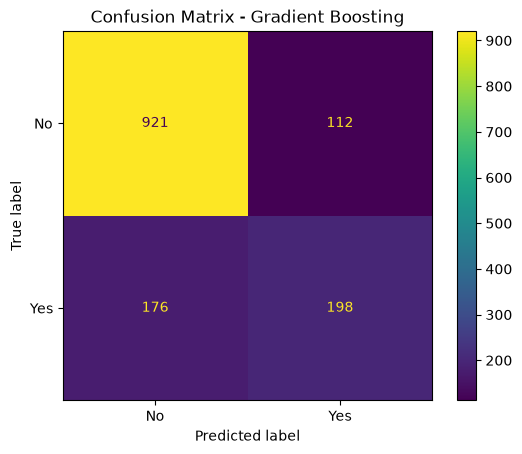

In [80]:
cm_gb = confusion_matrix(
    y_test,
    y_pred_gb,
    labels=["No", "Yes"]
)

disp = ConfusionMatrixDisplay(
    confusion_matrix=cm_gb,
    display_labels=["No", "Yes"]
)

disp.plot()
plt.title("Confusion Matrix - Gradient Boosting")
plt.show()

### ROC-AUC — Gradient Boosting

ROC-AUC measures how well the Gradient Boosting model distinguishes
between customers who churn and customers who do not churn.

A higher ROC-AUC indicates better class-separation performance.

In [81]:
y_prob_gb = gradient_boosting_model.predict_proba(X_test_processed)[:, 1]

roc_auc_gb = roc_auc_score(
    (y_test == "Yes").astype(int),
    y_prob_gb
)

print(f"ROC-AUC: {roc_auc_gb:.4f}")

ROC-AUC: 0.8391


### ROC Curve — Gradient Boosting

The ROC curve visualizes the relationship between the True Positive Rate
and False Positive Rate at different classification thresholds.

The AUC value represents the model's overall ability to distinguish
between churned and non-churned customers.

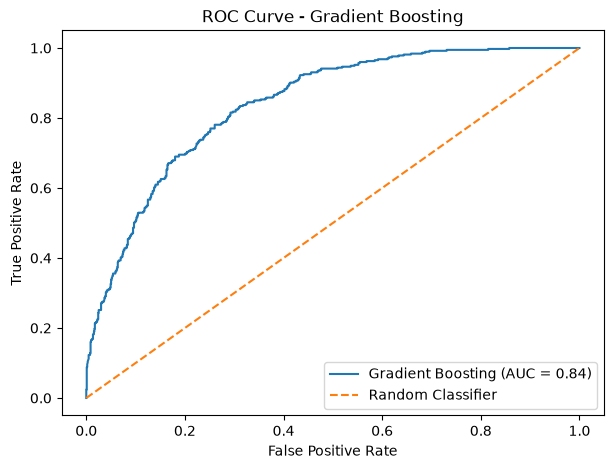

In [82]:
fpr_gb, tpr_gb, thresholds_gb = roc_curve(
    (y_test == "Yes").astype(int),
    y_prob_gb
)

plt.figure(figsize=(7, 5))

plt.plot(
    fpr_gb,
    tpr_gb,
    label=f"Gradient Boosting (AUC = {roc_auc_gb:.2f})"
)

plt.plot(
    [0, 1],
    [0, 1],
    linestyle="--",
    label="Random Classifier"
)

plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve - Gradient Boosting")
plt.legend()
plt.show()

### Model Comparison

The performance of Logistic Regression, Random Forest, and Gradient Boosting
will be compared using multiple evaluation metrics.

Since customer churn is an imbalanced classification problem, F1-score,
Recall, and ROC-AUC will be considered along with Accuracy and Precision.

In [83]:
model_comparison = pd.DataFrame({
    "Model": [
        "Logistic Regression",
        "Random Forest",
        "Gradient Boosting"
    ],
    "Accuracy": [
        accuracy_logistic,
        accuracy_rf,
        accuracy_gb
    ],
    "Precision": [
        precision_logistic,
        precision_rf,
        precision_gb
    ],
    "Recall": [
        recall_logistic,
        recall_rf,
        recall_gb
    ],
    "F1-Score": [
        f1_logistic,
        f1_rf,
        f1_gb
    ],
    "ROC-AUC": [
        roc_auc_logistic,
        roc_auc_rf,
        roc_auc_gb
    ]
})

model_comparison.round(4)

,Model,Accuracy,Precision,Recall,F1-Score,ROC-AUC
0,Logistic Regression,0.7925,0.6314,0.5267,0.5743,0.8350
1,Random Forest,0.7818,0.6136,0.4840,0.5411,0.8147
2,Gradient Boosting,0.7953,0.6387,0.5294,0.5789,0.8391


### Selecting the Best Model

The models are compared using F1-score as the primary metric because
customer churn prediction requires a balance between precision and recall.

ROC-AUC is also considered as an important secondary metric.

The model with the strongest overall performance will be selected
for deployment in the Streamlit application.

In [84]:
best_model_name = model_comparison.loc[
    model_comparison["F1-Score"].idxmax(),
    "Model"
]

print("Best Model based on F1-Score:", best_model_name)

Best Model based on F1-Score: Gradient Boosting


### Final Model Pipeline

The preprocessing steps and the selected Gradient Boosting model are combined
into a single machine learning pipeline.

This ensures that the same preprocessing applied during training is also
applied consistently when making predictions on new customer data.

In [85]:
final_model = Pipeline([
    ("preprocessor", preprocessor),
    ("model", GradientBoostingClassifier(
        n_estimators=100,
        learning_rate=0.1,
        random_state=42
    ))
])

final_model.fit(X_train, y_train)

print("Final model pipeline trained successfully.")

Final model pipeline trained successfully.


### Evaluating the Final Model Pipeline

The complete pipeline is evaluated on the original test dataset.

The pipeline automatically performs preprocessing before generating predictions.
This confirms that the complete workflow works correctly from raw features to prediction.

In [86]:
y_pred_final = final_model.predict(X_test)

y_prob_final = final_model.predict_proba(X_test)[:, 1]

accuracy_final = accuracy_score(y_test, y_pred_final)
precision_final = precision_score(y_test, y_pred_final, pos_label="Yes")
recall_final = recall_score(y_test, y_pred_final, pos_label="Yes")
f1_final = f1_score(y_test, y_pred_final, pos_label="Yes")

roc_auc_final = roc_auc_score(
    (y_test == "Yes").astype(int),
    y_prob_final
)

print("Final Gradient Boosting Model Performance")
print("------------------------------------------")
print(f"Accuracy : {accuracy_final:.4f}")
print(f"Precision: {precision_final:.4f}")
print(f"Recall   : {recall_final:.4f}")
print(f"F1-Score : {f1_final:.4f}")
print(f"ROC-AUC  : {roc_auc_final:.4f}")

Final Gradient Boosting Model Performance
------------------------------------------
Accuracy : 0.7953
Precision: 0.6387
Recall   : 0.5294
F1-Score : 0.5789
ROC-AUC  : 0.8391


### Saving the Final Model

The complete machine learning pipeline is saved using Joblib.

The saved pipeline contains both the preprocessing steps and the trained
Gradient Boosting model, allowing it to be reused for predictions without
retraining.

In [87]:
import joblib
import os

os.makedirs("../models", exist_ok=True)

model_path = "../models/churn_model.joblib"

joblib.dump(final_model, model_path)

print("Model saved successfully.")
print("Saved at:", model_path)

Model saved successfully.
Saved at: ../models/churn_model.joblib


### Loading the Saved Model

The saved machine learning pipeline is loaded from disk using Joblib.

This verifies that the trained model can be reused without retraining.

In [88]:
loaded_model = joblib.load("../models/churn_model.joblib")

print("Saved model loaded successfully.")
print("Model type:", type(loaded_model))

Saved model loaded successfully.
Model type: <class 'sklearn.pipeline.Pipeline'>


### Testing the Loaded Model

The saved model is used to generate predictions on the test dataset.

This confirms that the saved pipeline can independently perform predictions
after being loaded from disk.

In [89]:
loaded_predictions = loaded_model.predict(X_test)

print("First 10 predictions:")
print(loaded_predictions[:10])

print("\nNumber of predictions:", len(loaded_predictions))

First 10 predictions:
['No' 'Yes' 'No' 'No' 'No' 'No' 'No' 'No' 'Yes' 'No']

Number of predictions: 1407


### Final Model — Confusion Matrix

The confusion matrix of the final Gradient Boosting pipeline is visualized
to examine the number of correct and incorrect churn predictions.

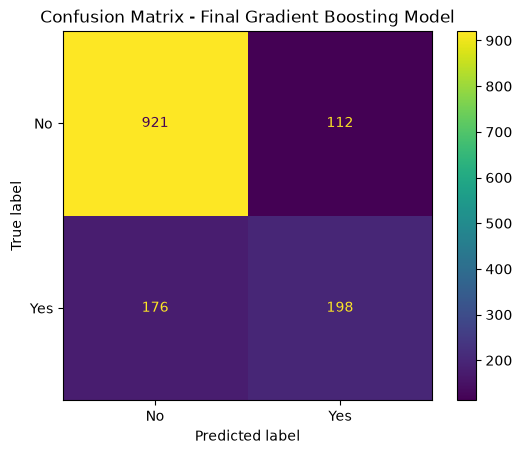

In [90]:
cm_final = confusion_matrix(
    y_test,
    y_pred_final,
    labels=["No", "Yes"]
)

disp = ConfusionMatrixDisplay(
    confusion_matrix=cm_final,
    display_labels=["No", "Yes"]
)

disp.plot()
plt.title("Confusion Matrix - Final Gradient Boosting Model")
plt.show()

### Final Model — ROC Curve

The ROC curve of the final Gradient Boosting pipeline is plotted to
visualize its ability to distinguish between churned and non-churned customers
at different classification thresholds.

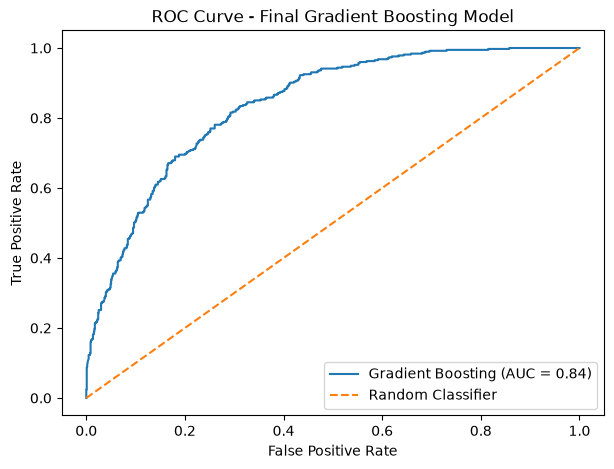

In [91]:
fpr_final, tpr_final, thresholds_final = roc_curve(
    (y_test == "Yes").astype(int),
    y_prob_final
)

plt.figure(figsize=(7, 5))

plt.plot(
    fpr_final,
    tpr_final,
    label=f"Gradient Boosting (AUC = {roc_auc_final:.2f})"
)

plt.plot(
    [0, 1],
    [0, 1],
    linestyle="--",
    label="Random Classifier"
)

plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve - Final Gradient Boosting Model")
plt.legend()
plt.show()

### Final Model Metrics Summary

The final Gradient Boosting model performance is summarized using
accuracy, precision, recall, F1-score, and ROC-AUC.

These metrics provide a complete evaluation of the model's predictive
performance on unseen test data.

In [92]:
final_metrics = pd.DataFrame({
    "Metric": [
        "Accuracy",
        "Precision",
        "Recall",
        "F1-Score",
        "ROC-AUC"
    ],
    "Score": [
        accuracy_final,
        precision_final,
        recall_final,
        f1_final,
        roc_auc_final
    ]
})

final_metrics["Score"] = final_metrics["Score"].round(4)

final_metrics

,Metric,Score
0,Accuracy,0.7953
1,Precision,0.6387
2,Recall,0.5294
3,F1-Score,0.5789
4,ROC-AUC,0.8391


### Single Customer Prediction Test

Before building the Streamlit application, we test the final saved model
with a single customer record.

This verifies that the model can accept raw customer information and return
both the predicted churn class and churn probability.

In [93]:
sample_customer = X_test.iloc[[0]]

sample_prediction = loaded_model.predict(sample_customer)[0]
sample_probability = loaded_model.predict_proba(sample_customer)[0][1]

print("Predicted Churn:", sample_prediction)
print(f"Churn Probability: {sample_probability:.2%}")

Predicted Churn: No
Churn Probability: 2.02%
